In [1]:
#------------------- IMPORT PACKAGES FOR DATA PROCESSING ----------------------#

# Manage datasets
import pandas as pd

# Work with time data
import time 

# Conduct HTTP requests
import requests

# Construct tree structure of HTML data
import html5lib

# Parse HTML data obtained from scraping
from bs4 import BeautifulSoup

# Import webdriver for chrome
from webdriver_manager.chrome import ChromeDriverManager



from selenium import webdriver
from webdriver_manager.chrome import ChromeDriverManager


# Automate navigating within browser (SELENIUM)
#------ Key: Manage keys
#------ Select: Obtain features from website
#------ WebDriverWait: Add wait times implicitly
#------ By: Use common information locator strategies
#------ EC and Options: Browser configuration
#------ remote.command: Check whether browser is active

from selenium import webdriver #to automate the navigating within the browser
from selenium.webdriver.chrome.service import service
from selenium.webdriver.common.keys    import Keys
from selenium.webdriver.support.ui     import Select
from selenium.webdriver.support.ui     import WebDriverWait 
from selenium.webdriver.common.by      import By
from selenium.webdriver.support        import expected_conditions as EC
from selenium.webdriver.chrome.options import Options #to use properties of the chrome webbrowser
from selenium.webdriver.remote.command import Command # Use to check whether the web driver is active

In [ ]:
# Create a directory to save JSON files 
import os
import json
import requests
os.makedirs("json_files2", exist_ok=True) 


import requests, jmespath

BASE = "https://api.openalex.org/works" # base URL for works endpoint
params = {
    "filter": "title.search:artificial intelligence", # search for works with "artificial intelligence" in the title
    "per_page": 25, # number of results per page
    
}
data = requests.get(BASE, params=params, timeout=60).json() # make the GET request and parse the JSON response

titles = jmespath.search("results[].title", data) # extract the titles of the works using jmespath
print("Matches on this page:", len(titles))  # page count (not global)

with open('json_files2/convert_search_results.json', 'w') as file:
    file.write(json.dumps(data, indent=4))


#There are 25 titles with AI in the title, but this is only for this page. 

Matches on this page: 25


In [4]:
import requests, jmespath, pandas as pd

BASE = "https://api.openalex.org/works"
params = {
    "filter": "title.search:artificial intelligence,from_publication_date:2020-01-01",
    "group_by": "institutions.country_code",    # <-- use code, not name
    "per-page": 1,                              # use hyphen, OpenAlex style
    "mailto": "jeremy.anderson@emory.edu"
}

r = requests.get(BASE, params=params, timeout=60)
print("HTTP status:", r.status_code)
print("URL:", r.url)

data = r.json()
if "error" in data:
    print("OpenAlex error:", data.get("message", data["error"]))
else:
    rows = jmespath.search(
        "group_by[].{country: (key_display_name || key), country_code: key, count: count}",
        data
    ) or []

    print("Number of rows:", len(rows))
    df = pd.DataFrame(rows).sort_values("count", ascending=False).reset_index(drop=True)
    display(df.head(20))




HTTP status: 200
URL: https://api.openalex.org/works?filter=title.search%3Aartificial+intelligence%2Cfrom_publication_date%3A2020-01-01&group_by=institutions.country_code&per-page=1&mailto=jeremy.anderson%40emory.edu
Number of rows: 1


,country,country_code,count
0,United States of America,https://openalex.org/countries/US,20141


In [19]:
import requests, jmespath, pandas as pd, json

BASE = "https://api.openalex.org/works"
params = {
    # Filter: AI in title AND year >= 2020
    "filter": "title.search:artificial intelligence,from_publication_date:2020-01-01",

    # Group by authors' institution country (use code; this is reliably supported)
    "group_by": "institutions.country_code",

    # Only need meta/group_by rows, not the works list
    "per-page": 1,                 # use hyphen style here
    "mailto": "jeremy.anderson@emory.edu"    # <-- put your real email
}

r = requests.get(BASE, params=params, headers={"Accept": "application/json"}, timeout=60)
print("HTTP status:", r.status_code)
print("Request URL:", r.url)
data = r.json()

# If API returned an error, show it and stop
if "error" in data:
    print("OpenAlex error:", data.get("message", data["error"]))
else:
    # Peek at group_by to confirm shape
    print("Top-level keys:", list(data.keys()))
    print("Meta keys:", list(data.get("meta", {}).keys()))
    print("group_by sample:", json.dumps(data.get("group_by", [])[:5], indent=2))

    # Extract with JMESPath (handle key_display_name if present)
    rows = jmespath.search(
        "group_by[].{country: (key_display_name || key), country_code: key, count: count}",
        data
    ) or []

    df = pd.DataFrame(rows).sort_values("count", ascending=False).reset_index(drop=True)
    print(df.head(20))




HTTP status: 200
Request URL: https://api.openalex.org/works?filter=title.search%3Aartificial+intelligence%2Cfrom_publication_date%3A2020-01-01&group_by=institutions.country_code&per-page=1&mailto=jeremy.anderson%40emory.edu
Top-level keys: ['meta', 'group_by']
Meta keys: ['count', 'db_response_time_ms', 'page', 'per_page', 'groups_count']
group_by sample: [
  {
    "key": "https://openalex.org/countries/US",
    "key_display_name": "United States of America",
    "count": 20141
  }
]
                    country                       country_code  count
0  United States of America  https://openalex.org/countries/US  20141


In [ ]:
import requests, jmespath, pandas as pd
from collections import Counter
import json

BASE = "https://api.openalex.org/works"
params = {
    "filter": "title.search:artificial intelligence,from_publication_date:2020-01-01",
    "per-page": 200,         # max per request
    "cursor": "*",
    "mailto": "jeremy.anderson@emory.edu"  # real email (good!)
}

counts = Counter()
pages = 5  # pull ~1000 works for a demo; increase if needed

for i in range(pages):
    r = requests.get(BASE, params=params, timeout=60)
    try:
        data = r.json()
    except Exception:
        print("Could not parse JSON. HTTP status:", r.status_code)
        print("URL:", r.url)
        break

    # 1) DIAG: show status & handle server error
    if "error" in data:
        print("OpenAlex error:", data.get("message", data["error"]))
        print("URL:", r.url)
        break

    print(f"Page {i+1}: status {r.status_code}, results={len(data.get('results', []))}")

    # 2) Use a reliable field: country **code** (name can be missing)
    countries = jmespath.search(
        "results[].authorships[].institutions[].country_code", data
    ) or []

    # drop Nones / empty
    counts.update([c for c in countries if c])

    # paginate
    nxt = data.get("meta", {}).get("next_cursor")
    if not nxt:
        break
    params["cursor"] = nxt

# build table
df = pd.DataFrame(counts.items(), columns=["country_code", "count"]) \
       .sort_values("count", ascending=False).reset_index(drop=True)

df.head(20)

#The top ten countries are listed in the table below. 

Page 1: status 200, results=200
Page 2: status 200, results=200
Page 3: status 200, results=200
Page 4: status 200, results=200
Page 5: status 200, results=200


,country_code,count
0,US,1845
1,GB,774
2,CN,667
3,DE,311
4,CA,308
5,IN,243
6,NL,204
7,FR,190
8,AU,182
9,IT,179


In [ ]:
import requests, jmespath, pandas as pd

BASE = "https://api.openalex.org/works"
params = {
    "filter": "title.search:artificial intelligence,from_publication_date:2020-01-01",
    "sort": "cited_by_count:desc",   # highest cited first
    "per-page": 10,                  # just top 10
    "mailto": "jeremy.anderson@emory.edu"
}

r = requests.get(BASE, params=params, timeout=60)
data = r.json()

if "error" in data:
    raise RuntimeError(data.get("message", data["error"]))

# --- JMESPath: pick out the bits we need ---
rows = jmespath.search(
    """
    results[].{
        title: title,
        citations: cited_by_count,
        authors: authorships[].author.display_name,
        institutions: authorships[].institutions[].display_name
    }
    """,
    data
) or []

# --- Clean up lists for nice display ---
def uniq_join(xs):
    return ", ".join(sorted({x for x in xs if x}))

df = pd.DataFrame(rows)
df["authors"] = df["authors"].apply(uniq_join)
df["institutions"] = df["institutions"].apply(uniq_join)

df = df[["title", "citations", "authors", "institutions"]]
df

# ##The titles of the names of the 10 most highly cited papers with "artificial intelligence" in the title published since 2020 are in the table below. 
# The citations range between 1,385 amd 2,249.
# All of the authors are associated with universities


,title,citations,authors,institutions
0,Artificial Intelligence in Education: A Review,2249,"Lijia Chen, Pingping Chen, Zhijian Lin","Fuzhou University, Yango University"
1,The role of artificial intelligence in achievi...,2195,"Anna Felländer, Francesco Fuso Nerini, Hossein...","Basque Centre for Climate Change, KTH Royal In..."
2,Using Artificial Intelligence to Detect COVID-...,1956,"Bin Kong, Daliang Liu, Guisheng Wang, Juan Xia...","Chinese PLA General Hospital, Jianghan Univers..."
3,Revolutionizing healthcare: the role of artifi...,1629,"Abdulkareem Albekairy, Abdulrahman Alshaya, At...","King Abdulaziz Medical City, King Abdullah Int..."
4,Comparing Physician and Artificial Intelligenc...,1576,"Aaron M. Goodman, Adam Poliak, Chris Longhurst...","Bryn Mawr College, Human Longevity (United Sta..."
5,A Survey on Explainable Artificial Intelligenc...,1560,"Cuntai Guan, Erico Tjoa","Alibaba Group (China), Nanyang Technological U..."
6,Artificial Intelligence (AI) applications for ...,1414,"Abid Haleem, Ibrahim Haleem Khan, Mohd Javaid,...","Indraprastha Apollo Hospitals, Jamia Millia Is..."
7,Human Trust in Artificial Intelligence: Review...,1405,"Anita Williams Woolley, Ella Glikson","Bar-Ilan University, Carnegie Mellon University"
8,Review of Artificial Intelligence Techniques i...,1396,"Dinggang Shen, Feng Shi, Jun Shi, Jun Wang, Ke...","Beihang University, Beijing Advanced Sciences ..."
9,Photonics for artificial intelligence and neur...,1385,"Alexander N. Tait, Bhavin J. Shastri, C. David...","Princeton University, Queen's University, Univ..."


In [9]:
import requests, jmespath, pandas as pd
from collections import Counter

BASE = "https://api.openalex.org/works"
MAILTO = "your.real.email@domain.com"

def count_by_year_locally(term, start="2000-01-01", pages=10):
    params = {
        "filter": f'title.search:{term},from_publication_date:{start}',
        "per-page": 200,
        "cursor": "*",
        "mailto": MAILTO
    }
    counts = Counter()
    for _ in range(pages):
        r = requests.get(BASE, params=params, timeout=60)
        data = r.json()
        if "error" in data:
            raise RuntimeError(data.get("message", data["error"]))
        years = jmespath.search("results[].publication_year", data) or []
        counts.update([y for y in years if y is not None])
        nxt = data.get("meta", {}).get("next_cursor")
        if not nxt:
            break
        params["cursor"] = nxt
    df = (pd.DataFrame(sorted(counts.items()), columns=["year", "count"])
            .astype({"year": int, "count": int}))
    return df

ai_local  = count_by_year_locally("artificial intelligence", pages=10)   # ~2000 results
llm_local = count_by_year_locally("LLM", pages=10).merge(
               count_by_year_locally("large language model", pages=10),
               on="year", how="outer", suffixes=("_a","_b")).fillna(0)
llm_local["LLM_or_LargeLangModel"] = llm_local["count_a"].astype(int) + llm_local["count_b"].astype(int)
gpt_local = count_by_year_locally("GPT", pages=10).merge(
               count_by_year_locally("ChatGPT", pages=10),
               on="year", how="outer", suffixes=("_a","_b")).fillna(0)
gpt_local["GPT_or_ChatGPT"] = gpt_local["count_a"].astype(int) + gpt_local["count_b"].astype(int)

years = pd.DataFrame({"year": range(2000, pd.Timestamp.today().year + 1)})
final_df_local = (years
    .merge(ai_local.rename(columns={"count":"AI"}), on="year", how="left")
    .merge(llm_local[["year","LLM_or_LargeLangModel"]], on="year", how="left")
    .merge(gpt_local[["year","GPT_or_ChatGPT"]], on="year", how="left")
    .fillna(0).astype(int))

final_df_local.tail(15)



,year,AI,LLM_or_LargeLangModel,GPT_or_ChatGPT
11,2011,21,15,10
12,2012,22,7,21
13,2013,20,8,13
14,2014,29,15,15
15,2015,36,4,16
16,2016,58,14,13
17,2017,104,11,12
18,2018,238,12,13
19,2019,338,14,26
20,2020,389,15,46


,year,key_display_name,n,term
5,2016,2016,10,Sports Analytics
6,2017,2017,12,Sports Analytics
7,2018,2018,23,Sports Analytics
8,2019,2019,36,Sports Analytics
9,2020,2020,17,Sports Analytics
10,2021,2021,12,Sports Analytics
11,2022,2022,19,Sports Analytics
12,2023,2023,22,Sports Analytics
13,2024,2024,47,Sports Analytics
14,2025,2025,29,Sports Analytics


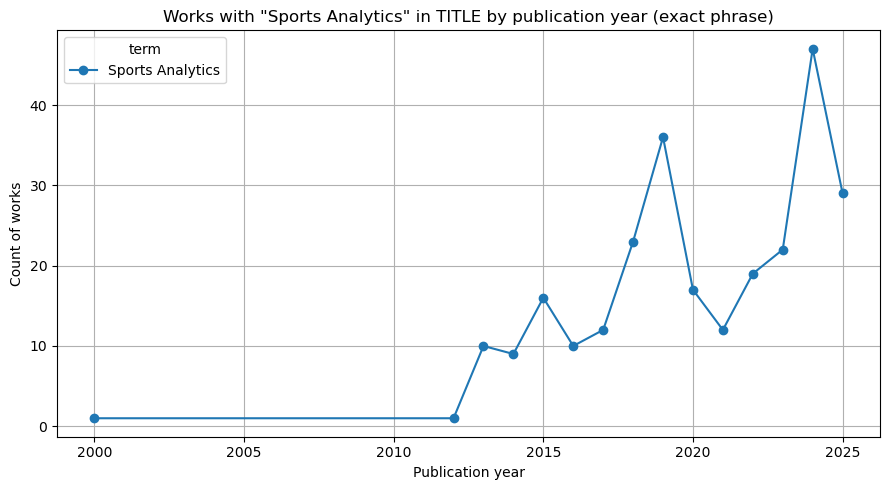

In [10]:
# --- Imports (used for the request, table, and plot) ---
import requests                 # HTTP calls to OpenAlex
import pandas as pd             # tidy tables
import matplotlib.pyplot as plt # simple plotting
from datetime import datetime   # current year for the range

# --- Reuse your earlier constants (define if you haven't already) ---
BASE   = "https://api.openalex.org/works"           # Works endpoint
MAILTO = "jeremy.anderson@emory.edu"               # <-- put YOUR real email
HEADERS = {                                         # explicit headers help avoid 403s
    "Accept": "application/json",
    "User-Agent": f"datasci530-hw (mailto:{MAILTO})"
}

YEAR_START = 2000                  # start year for the analysis window
YEAR_END   = datetime.now().year   # end at current year (updates automatically)

# === Choose your NEW keyword here ===
NEW_TERM = "Sports Analytics"   # <-- change to anything you want

# If you want exact phrase matching in TITLES, keep quoted=True.
# Set quoted=False to match titles that contain the words anywhere (broader, noisier).
QUOTED = True

# --- Helper: fetch year-by-year counts for a TITLE term from OpenAlex ---
def yearly_counts_for_title(term, quoted=True, y0=YEAR_START, y1=YEAR_END):
    """
    Returns a DataFrame with columns [year, n, term] for works whose TITLE matches `term`
    between years y0..y1 (inclusive), using server-side group_by=publication_year.
    quoted=True -> exact phrase (e.g., "reinforcement learning")
    quoted=False -> broader token match (words anywhere in the title)
    """
    # Build the title filter (OpenAlex is case-insensitive; quotes enforce exact phrase)
    title_filter = f'title.search:"{term}"' if quoted else f"title.search:{term}"

    # Compose query params (comma = logical AND for filters in OpenAlex)
    params = {
        "filter": f"{title_filter},publication_year:{y0}-{y1}",
        "group_by": "publication_year",   # return one row per year with a 'count'
        "per-page": 200,                  # enough to return all years at once
        "sort": "key:asc",                # order by the year key ascending
        "mailto": MAILTO
    }

    # Make the HTTP request
    r = requests.get(BASE, params=params, headers=HEADERS, timeout=60)
    r.raise_for_status()                  # raise an error if not 200 OK
    data = r.json()                       # parse JSON -> Python dict

    # Convert the grouped list ({key:year, count:n}) into a DataFrame
    df = pd.DataFrame(data.get("group_by", [])) \
           .rename(columns={"key": "year", "count": "n"})

    # Clean types & label with the searched term
    if not df.empty:
        df["year"] = df["year"].astype(int)
        df["n"]    = df["n"].astype(int)
        df["term"] = term
    return df

# --- Run the analysis for your NEW keyword ---
new_series = yearly_counts_for_title(NEW_TERM, quoted=QUOTED)

# Sanity check: show the last few years
display(new_series.tail(10))

# --- Pivot to wide (optional) and make a plot ---
# For a single series we can plot directly, but pivot keeps the pattern consistent.
wide = new_series.pivot(index="year", columns="term", values="n").fillna(0).astype(int)

# Plot the trend for your chosen term
ax = wide.plot(figsize=(9, 5), marker="o")
ax.set_title(f'Works with "{NEW_TERM}" in TITLE by publication year'
             + (" (exact phrase)" if QUOTED else " (broad match)"))
ax.set_xlabel("Publication year")
ax.set_ylabel("Count of works")
ax.grid(True)
plt.tight_layout()
plt.show()